1. Cài đặt & import các thư viện cần thiết

In [1]:
# =========================
# 1. SETUP
# =========================

!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

plt.rcParams["figure.figsize"] = (8, 5)

2. Load dataset

In [2]:
# =========================
# 2. LOAD DATASET
# =========================

dataset = load_dataset("dbpedia_14")

train_data = dataset["train"]
test_data = dataset["test"]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

# label names
label_names = train_data.features["label"].names

print("\nNumber of classes:", len(label_names))
print("Classes:", label_names)

print("\nSample:")
print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Train size: 560000
Test size: 70000

Number of classes: 14
Classes: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']

Sample:
{'label': 0, 'title': 'E. D. Abbott Ltd', 'content': ' Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contract to motor vehicle manufacturers. Their business closed in 1972.'}


3. Tính độ dài văn bản

In [3]:
# =========================
# 3. COMPUTE LENGTH
# =========================

def compute_lengths(example):
    title = example["title"]
    content = example["content"]

    full_text = title + " " + content

    return {
        "title_len": len(title.split()),
        "content_len": len(content.split()),
        "total_len": len(full_text.split())
    }

train_data = train_data.map(compute_lengths)

Map:   0%|          | 0/560000 [00:00<?, ? examples/s]

4. Thống kê số liệu

In [5]:
# =========================
# EXTRACT ARRAYS
# =========================

title_lengths = np.array(train_data["title_len"])
content_lengths = np.array(train_data["content_len"])
total_lengths = np.array(train_data["total_len"])
labels = np.array(train_data["label"])

# =========================
# STATISTICS
# =========================

def print_stats(name, arr):
    print(f"\n{name}:")
    print("Mean   :", np.mean(arr))
    print("Median :", np.median(arr))
    print("Min    :", np.min(arr))
    print("Max    :", np.max(arr))

print_stats("Title length", title_lengths)
print_stats("Content length", content_lengths)
print_stats("Total length", total_lengths)


Title length:
Mean   : 2.7407160714285714
Median : 2.0
Min    : 1
Max    : 31

Content length:
Mean   : 46.13323392857143
Median : 46.0
Min    : 1
Max    : 1484

Total length:
Mean   : 48.87395
Median : 49.0
Min    : 2
Max    : 1485


6. Histogram độ dài

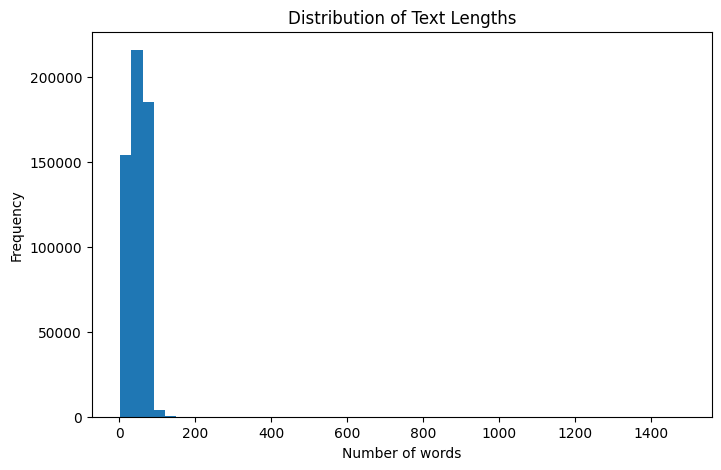

In [6]:
# =========================
# 6. HISTOGRAM TOTAL LENGTH
# =========================

plt.figure()
plt.hist(total_lengths, bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.savefig("hist_total_length.png")
plt.show()

So sánh Title vs Content

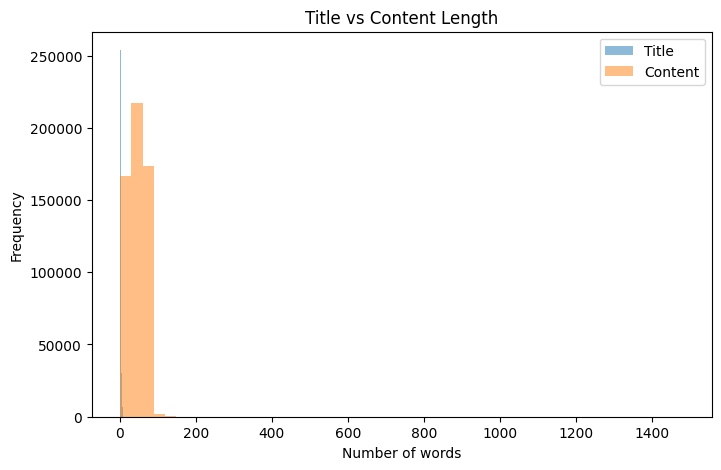

In [7]:
# =========================
# 7. TITLE VS CONTENT
# =========================

plt.figure()
plt.hist(title_lengths, bins=50, alpha=0.5, label="Title")
plt.hist(content_lengths, bins=50, alpha=0.5, label="Content")
plt.legend()
plt.title("Title vs Content Length")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.savefig("hist_title_vs_content.png")
plt.show()

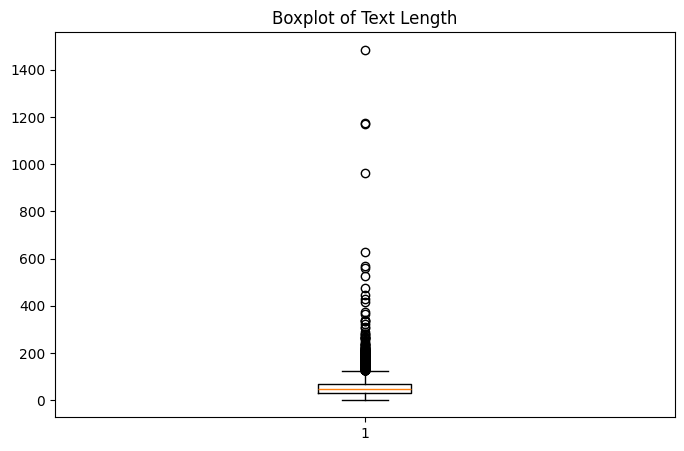

In [8]:
# =========================
# 8. BOXPLOT
# =========================

plt.figure()
plt.boxplot(total_lengths)
plt.title("Boxplot of Text Length")
plt.savefig("boxplot_length.png")
plt.show()

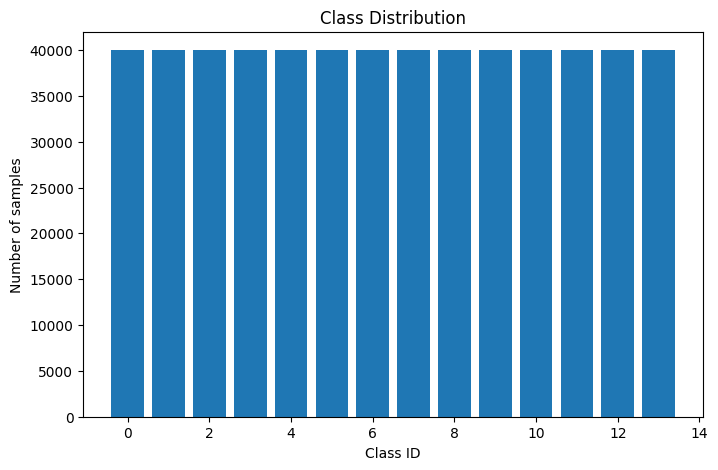


Samples per class:
Company: 40000
EducationalInstitution: 40000
Artist: 40000
Athlete: 40000
OfficeHolder: 40000
MeanOfTransportation: 40000
Building: 40000
NaturalPlace: 40000
Village: 40000
Animal: 40000
Plant: 40000
Album: 40000
Film: 40000
WrittenWork: 40000


In [9]:
# =========================
# 9. CLASS DISTRIBUTION
# =========================

label_counts = Counter(labels)

plt.figure()
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of samples")
plt.savefig("class_distribution.png")
plt.show()

print("\nSamples per class:")
for k, v in label_counts.items():
    print(f"{label_names[k]}: {v}")

In [10]:
# =========================
# 10. TOP WORDS
# =========================

all_words = []

# lấy subset để nhanh
for i in range(50000):
    text = train_data[i]["title"] + " " + train_data[i]["content"]
    words = text.lower().split()
    all_words.extend(words)

counter = Counter(all_words)

top_words = counter.most_common(20)

print("\nTop 20 words:")
for w, c in top_words:
    print(w, ":", c)


Top 20 words:
the : 125665
in : 102582
and : 94614
of : 75279
is : 68913
a : 60335
was : 30195
company : 29227
school : 26304
to : 25001
it : 22957
by : 22840
as : 20677
for : 17827
an : 14884
with : 13940
its : 12378
founded : 12212
on : 12080
high : 10919


In [11]:
# =========================
# 11. AUTO INSIGHT
# =========================

mean_len = np.mean(total_lengths)
max_len = np.max(total_lengths)

print("\n===== EDA INSIGHTS =====")

print(f"- Average length ~ {mean_len:.1f} words")
print(f"- Max length ~ {max_len} words")

if mean_len > 100:
    print("- Texts are relatively long → challenging for RNN")

print("- Dataset is balanced across classes → accuracy is reliable")
print("- Content is much longer than title → main information lies in content")
print("- Suitable for comparing RNN vs Transformer")


===== EDA INSIGHTS =====
- Average length ~ 48.9 words
- Max length ~ 1485 words
- Dataset is balanced across classes → accuracy is reliable
- Content is much longer than title → main information lies in content
- Suitable for comparing RNN vs Transformer
